# Reconocimiento facial mediante Transfer Learning con CelebA

En este ejercicio buscaré entrenar una red neuronal que reconozca mi rostro. Debido a que no cuento con una base de datos demasiado grande de fotos mias, usaremos una técnica de pre-entrenamiento llamada Transfer-Learning

## Introducción

El reconocimiento facial puede abordarse mediante diferentes etapas, entre ellas la detección y alineación del rostro, la extracción de características y la clasificación. En este trabajo se aborda principalmente la etapa de extracción de características mediante una red neuronal convolucional (CNN) entrenada inicialmente con el conjunto de datos CelebA.

CelebA (Large-scale CelebFaces Attributes Dataset) contiene imágenes de rostros acompañadas de 40 atributos faciales binarios. Estos atributos permiten entrenar una red neuronal para aprender representaciones relacionadas con características visuales del rostro.

Una vez entrenada la CNN con CelebA, se reutilizan sus capas convolucionales como extractor de características. Posteriormente, se incorpora un nuevo clasificador binario cuyo objetivo es distinguir entre dos clases: imágenes correspondientes a la autora del experimento (`yo`) e imágenes de otras personas (`otros`).

Finalmente, se realiza un proceso de fine-tuning mediante el descongelamiento de la última capa convolucional, permitiendo que parte de las características previamente aprendidas se adapte a la nueva tarea.


## Objetivos

* Entrenar una CNN para predecir los 40 atributos faciales presentes en CelebA.
* Utilizar las capas convolucionales aprendidas como extractor de características.
* Incorporar un clasificador binario para distinguir entre las clases `yo` y `otros`.
* Aplicar aumento de datos mediante `ImageDataGenerator` sobre las imágenes de entrenamiento.
* Entrenar el nuevo clasificador manteniendo congeladas las capas convolucionales previamente entrenadas.
* Realizar fine-tuning mediante el descongelamiento de la última capa convolucional.
* Evaluar el desempeño del modelo mediante accuracy, matriz de confusión, precision, recall y F1-score.


In [9]:
#Preparación
!pip install -q tensorflow-datasets

In [5]:
!pip install -U protobuf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 11.4 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.2 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.2 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.2 which is incompatible.


In [5]:
!pip install -U importlib_resources

In [15]:
!pip install -q huggingface_hub

In [6]:
import tensorflow as tf
import tensorflow_datasets as tfds

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))
print("tfds.load disponible:", hasattr(tfds, "load"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
tfds.load disponible: True


In [16]:
import huggingface_hub

print(huggingface_hub.__version__)

1.29.0


## Dataset CelebA

Para la primera etapa del experimento se utilizó el conjunto CelebA. El dataset contiene 202,599 imágenes de rostros y 40 atributos faciales binarios por imagen.

Las imágenes fueron redimensionadas a `128 × 128` píxeles y los valores de los píxeles fueron normalizados al intervalo `[0,1]`.

La partición proporcionada por el dataset se utilizó para separar las imágenes en conjuntos de entrenamiento, validación y prueba. En particular, se obtuvieron:

* Entrenamiento: 162,770 imágenes.
* Validación: 19,867 imágenes.
* Prueba: 19,962 imágenes.

Los 40 atributos faciales fueron transformados de los valores originales `{-1, 1}` a etiquetas binarias `{0, 1}`.

Para la carga eficiente de las imágenes se utilizó `tf.data`, incorporando operaciones de lectura, decodificación, redimensionamiento, normalización, agrupamiento en lotes y prefetching.


In [17]:
#Cargar ZIP de CelebA
from huggingface_hub import snapshot_download

snapshot_download(
    repo_id="Yuehao/celeba",
    repo_type="dataset",
    local_dir="/content/celeba"
)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

'/content/celeba'

In [18]:
import os

for archivo in os.listdir("/content/celeba"):
    print(archivo)

README.md
list_eval_partition.txt
img_align_celeba.zip
.gitattributes
list_bbox_celeba.txt
list_landmarks_align_celeba.txt
.cache
identity_CelebA.txt
list_attr_celeba.txt


In [19]:
#Descomprimir
import zipfile

zip_path = "/content/celeba/img_align_celeba.zip"
extract_path = "/content/celeba/images"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("¡Imágenes extraídas!")

¡Imágenes extraídas!


In [20]:
import os

imagenes = os.listdir("/content/celeba/images/img_align_celeba")

print("Número de imágenes:", len(imagenes))
print("Primeras 5:", imagenes[:5])

Número de imágenes: 202599
Primeras 5: ['003507.jpg', '169453.jpg', '128069.jpg', '106652.jpg', '067112.jpg']


In [21]:
with open("/content/celeba/list_attr_celeba.txt", "r") as f:
    for _ in range(3):
        print(f.readline().strip())

202599
5_o_Clock_Shadow Arched_Eyebrows Attractive Bags_Under_Eyes Bald Bangs Big_Lips Big_Nose Black_Hair Blond_Hair Blurry Brown_Hair Bushy_Eyebrows Chubby Double_Chin Eyeglasses Goatee Gray_Hair Heavy_Makeup High_Cheekbones Male Mouth_Slightly_Open Mustache Narrow_Eyes No_Beard Oval_Face Pale_Skin Pointy_Nose Receding_Hairline Rosy_Cheeks Sideburns Smiling Straight_Hair Wavy_Hair Wearing_Earrings Wearing_Hat Wearing_Lipstick Wearing_Necklace Wearing_Necktie Young
000001.jpg -1  1  1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1  1  1 -1  1 -1 -1  1 -1 -1  1 -1 -1 -1  1  1 -1  1 -1  1 -1 -1  1


In [22]:
#Cargar etiquetas
import pandas as pd

attr_path = "/content/celeba/list_attr_celeba.txt"

# Leer el archivo de atributos
attributes = pd.read_csv(
    attr_path,
    sep=r"\s+",
    skiprows=1
)

print("Número de imágenes:", attributes.shape[0])
print("Número de atributos:", attributes.shape[1] - 1)
print(attributes.head())

Número de imágenes: 202599
Número de atributos: 39
            5_o_Clock_Shadow  Arched_Eyebrows  Attractive  Bags_Under_Eyes  \
000001.jpg                -1                1           1               -1   
000002.jpg                -1               -1          -1                1   
000003.jpg                -1               -1          -1               -1   
000004.jpg                -1               -1           1               -1   
000005.jpg                -1                1           1               -1   

            Bald  Bangs  Big_Lips  Big_Nose  Black_Hair  Blond_Hair  ...  \
000001.jpg    -1     -1        -1        -1          -1          -1  ...   
000002.jpg    -1     -1        -1         1          -1          -1  ...   
000003.jpg    -1     -1         1        -1          -1          -1  ...   
000004.jpg    -1     -1        -1        -1          -1          -1  ...   
000005.jpg    -1     -1         1        -1          -1          -1  ...   

            Sideburns  

In [23]:
# Convertir las etiquetas de -1/1 a 0/1
attributes = (attributes + 1) / 2

print(attributes.shape)
print(attributes.iloc[:5, :5])

(202599, 40)
            5_o_Clock_Shadow  Arched_Eyebrows  Attractive  Bags_Under_Eyes  \
000001.jpg               0.0              1.0         1.0              0.0   
000002.jpg               0.0              0.0         0.0              1.0   
000003.jpg               0.0              0.0         0.0              0.0   
000004.jpg               0.0              0.0         1.0              0.0   
000005.jpg               0.0              1.0         1.0              0.0   

            Bald  
000001.jpg   0.0  
000002.jpg   0.0  
000003.jpg   0.0  
000004.jpg   0.0  
000005.jpg   0.0  


In [24]:
#Revisar particiones
partition_path = "/content/celeba/list_eval_partition.txt"

with open(partition_path, "r") as f:
    for _ in range(5):
        print(f.readline().strip())

000001.jpg 0
000002.jpg 0
000003.jpg 0
000004.jpg 0
000005.jpg 0


In [25]:
partition = pd.read_csv(
    partition_path,
    sep=r"\s+",
    header=None,
    names=["image", "partition"]
)

print(partition.head())
print("\nCantidad por partición:")
print(partition["partition"].value_counts().sort_index())

        image  partition
0  000001.jpg          0
1  000002.jpg          0
2  000003.jpg          0
3  000004.jpg          0
4  000005.jpg          0

Cantidad por partición:
partition
0    162770
1     19867
2     19962
Name: count, dtype: int64


In [26]:
data = attributes.copy()

data["partition"] = partition["partition"].values

print(data.shape)
print(data.head())

(202599, 41)
            5_o_Clock_Shadow  Arched_Eyebrows  Attractive  Bags_Under_Eyes  \
000001.jpg               0.0              1.0         1.0              0.0   
000002.jpg               0.0              0.0         0.0              1.0   
000003.jpg               0.0              0.0         0.0              0.0   
000004.jpg               0.0              0.0         1.0              0.0   
000005.jpg               0.0              1.0         1.0              0.0   

            Bald  Bangs  Big_Lips  Big_Nose  Black_Hair  Blond_Hair  ...  \
000001.jpg   0.0    0.0       0.0       0.0         0.0         0.0  ...   
000002.jpg   0.0    0.0       0.0       1.0         0.0         0.0  ...   
000003.jpg   0.0    0.0       1.0       0.0         0.0         0.0  ...   
000004.jpg   0.0    0.0       0.0       0.0         0.0         0.0  ...   
000005.jpg   0.0    0.0       1.0       0.0         0.0         0.0  ...   

            Smiling  Straight_Hair  Wavy_Hair  Wearing_Earrin

In [27]:
train_data = data[data["partition"] == 0]
val_data   = data[data["partition"] == 1]
test_data  = data[data["partition"] == 2]

print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

Train: 162770
Validation: 19867
Test: 19962


In [28]:
# preparar los nombres, rutas y etiquetas
import numpy as np

IMG_SIZE = (128, 128)

attribute_names = attributes.columns.tolist()

def preparar_dataframe(df):
    image_names = df.index.to_numpy()

    image_paths = np.array([
        f"/content/celeba/images/img_align_celeba/{nombre}"
        for nombre in image_names
    ])

    labels = df[attribute_names].to_numpy(dtype=np.float32)

    return image_paths, labels

train_paths, train_labels = preparar_dataframe(train_data)
val_paths, val_labels = preparar_dataframe(val_data)
test_paths, test_labels = preparar_dataframe(test_data)

print("Train:", train_paths.shape, train_labels.shape)
print("Validation:", val_paths.shape, val_labels.shape)
print("Test:", test_paths.shape, test_labels.shape)

Train: (162770,) (162770, 40)
Validation: (19867,) (19867, 40)
Test: (19962,) (19962, 40)


In [29]:
def cargar_imagen(ruta, etiqueta):
    imagen = tf.io.read_file(ruta)
    imagen = tf.image.decode_jpeg(imagen, channels=3)
    imagen = tf.image.resize(imagen, IMG_SIZE)
    imagen = tf.cast(imagen, tf.float32) / 255.0

    return imagen, etiqueta

In [30]:
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
    .shuffle(10000)
    .map(cargar_imagen, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
    .map(cargar_imagen, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
    .map(cargar_imagen, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [31]:
imagenes, etiquetas = next(iter(train_ds))

print("Imágenes:", imagenes.shape)
print("Etiquetas:", etiquetas.shape)
print("Rango de píxeles:", tf.reduce_min(imagenes).numpy(),
      "a", tf.reduce_max(imagenes).numpy())

Imágenes: (64, 128, 128, 3)
Etiquetas: (64, 40)
Rango de píxeles: 0.0 a 1.0


### Arquitectura

La CNN está compuesta por tres capas convolucionales con 32, 64 y 128 filtros, respectivamente. Después de las dos primeras capas convolucionales se utiliza `MaxPooling2D` para reducir las dimensiones espaciales.

Posteriormente se utiliza `GlobalAveragePooling2D`, que transforma los mapas de características de la última capa convolucional en un vector de características de dimensión 128.

Finalmente, se utiliza una capa densa de 128 neuronas y una capa de salida de 40 neuronas con activación sigmoide. Esta última permite obtener una predicción binaria independiente para cada uno de los 40 atributos faciales.

La función de pérdida utilizada fue `binary_crossentropy` y el optimizador fue Adam.


In [32]:
from tensorflow import keras
from tensorflow.keras import layers

model_celeba = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),

    layers.Dense(40, activation="sigmoid")
])

model_celeba.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 40)             │         5,160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,920 (448.91 KB)

 Trainable params: 114,920 (448.91 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
model_celeba.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["binary_accuracy"]
)

In [36]:
history_celeba = model_celeba.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
2544/2544 ━━━━━━━━━━━━━━━━━━━━ 91s 36ms/step - binary_accuracy: 0.8456 - loss: 0.3497 - val_binary_accuracy: 0.8562 - val_loss: 0.3281
Epoch 2/5
2544/2544 ━━━━━━━━━━━━━━━━━━━━ 140s 35ms/step - binary_accuracy: 0.8586 - loss: 0.3204 - val_binary_accuracy: 0.8645 - val_loss: 0.3077
Epoch 3/5
2544/2544 ━━━━━━━━━━━━━━━━━━━━ 90s 35ms/step - binary_accuracy: 0.8671 - loss: 0.3020 - val_binary_accuracy: 0.8732 - val_loss: 0.2893
Epoch 4/5
2544/2544 ━━━━━━━━━━━━━━━━━━━━ 89s 35ms/step - binary_accuracy: 0.8738 - loss: 0.2876 - val_binary_accuracy: 0.8762 - val_loss: 0.2821
Epoch 5/5
2544/2544 ━━━━━━━━━━━━━━━━━━━━ 142s 35ms/step - binary_accuracy: 0.8787 - loss: 0.2764 - val_binary_accuracy: 0.8824 - val_loss: 0.2704


Después del entrenamiento, el modelo alcanzó una binary_accuracy de 0.8787 y una pérdida de 0.2764 en entrenamiento, mientras que en validación obtuvo una binary_accuracy de 0.8824 y una pérdida de 0.2704 en la última época registrada.

## Dataset para clasificación facial

Para adaptar las características aprendidas con CelebA a una tarea específica de identificación facial, se construyó un segundo conjunto de datos con dos clases:

* `yo`: imágenes propias.
* `otros`: imágenes de personas diferentes seleccionadas del conjunto CelebA.

Se utilizaron 31 imágenes propias y 100 imágenes de CelebA para representar la clase `otros`.

Los datos fueron divididos aleatoriamente utilizando una semilla fija (`seed=42`):

| Clase     | Entrenamiento | Validación |   Total |
| --------- | ------------: | ---------: | ------: |
| yo        |            25 |          6 |      31 |
| otros     |            80 |         20 |     100 |
| **Total** |       **105** |     **26** | **131** |

Las imágenes propias fueron almacenadas fuera del repositorio público y no se incorporaron al repositorio de GitHub.


In [38]:
#Cargar mis fotos
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [40]:
import os

ruta_fotos = "/content/drive/MyDrive/mis_fotos"

archivos = os.listdir(ruta_fotos)

print("Número de archivos:", len(archivos))
print("\nPrimeros archivos:")
for archivo in archivos[:10]:
    print(archivo)

Número de archivos: 31

Primeros archivos:
IMG_8015.JPG
IMG_8016.JPG
IMG_8017.JPG
IMG_8018.JPG
IMG_8019.JPG
IMG_8024.JPG
IMG_8026.JPG
IMG_8031.JPG
IMG_8032.JPG
IMG_8033.JPG


In [42]:
!pip install -q pillow-heif

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 54.5 MB/s eta 0:00:00


In [46]:
archivos_jpg = [
    archivo for archivo in os.listdir(ruta_salida)
    if archivo.lower().endswith(".jpg")
]

print("Número de imágenes JPG:", len(archivos_jpg))
print("Primeras imágenes:")
print(archivos_jpg[:10])

Número de imágenes JPG: 31
Primeras imágenes:
['IMG_8015.jpg', 'IMG_8016.jpg', 'IMG_8017.jpg', 'IMG_8018.jpg', 'IMG_8019.jpg', 'IMG_8024.jpg', 'IMG_8026.jpg', 'IMG_8031.jpg', 'IMG_8032.jpg', 'IMG_8033.jpg']


Ingresar la imagenes de CalebA para "OTROS"

In [47]:
import os
import random
import shutil

ruta_celeba = "/content/celeba/images/img_align_celeba"
ruta_otros = "/content/drive/MyDrive/celeba_otros"

os.makedirs(ruta_otros, exist_ok=True)

# Obtener imágenes de CelebA
imagenes_celeba = [
    archivo for archivo in os.listdir(ruta_celeba)
    if archivo.lower().endswith((".jpg", ".jpeg", ".png"))
]

# Seleccionar 100 imágenes al azar
random.seed(42)
seleccion = random.sample(imagenes_celeba, 100)

# Copiarlas
for archivo in seleccion:
    origen = os.path.join(ruta_celeba, archivo)
    destino = os.path.join(ruta_otros, archivo)
    shutil.copy2(origen, destino)

print("Imágenes de CelebA seleccionadas:", len(seleccion))

Imágenes de CelebA seleccionadas: 100


In [48]:
print("Imágenes en la clase 'otros':", len(os.listdir(ruta_otros)))

Imágenes en la clase 'otros': 100


Separación de Imágenes

In [49]:
import os
import shutil
import random

base_dataset = "/content/drive/MyDrive/dataset_rostros"

carpetas = [
    f"{base_dataset}/train/yo",
    f"{base_dataset}/train/otros",
    f"{base_dataset}/validation/yo",
    f"{base_dataset}/validation/otros"
]

for carpeta in carpetas:
    os.makedirs(carpeta, exist_ok=True)

print("Carpetas creadas correctamente.")

Carpetas creadas correctamente.


In [50]:
random.seed(42)

imagenes_yo = [
    archivo for archivo in os.listdir(ruta_salida)
    if archivo.lower().endswith(".jpg")
]

random.shuffle(imagenes_yo)

yo_train = imagenes_yo[:25]
yo_val = imagenes_yo[25:]

print("Yo - entrenamiento:", len(yo_train))
print("Yo - validación:", len(yo_val))

Yo - entrenamiento: 25
Yo - validación: 6


In [51]:
for archivo in yo_train:
    shutil.copy2(
        os.path.join(ruta_salida, archivo),
        os.path.join(base_dataset, "train", "yo", archivo)
    )

for archivo in yo_val:
    shutil.copy2(
        os.path.join(ruta_salida, archivo),
        os.path.join(base_dataset, "validation", "yo", archivo)
    )

print("Fotos de 'yo' organizadas.")

Fotos de 'yo' organizadas.


In [52]:
imagenes_otros = [
    archivo for archivo in os.listdir(ruta_otros)
    if archivo.lower().endswith(".jpg")
]

random.shuffle(imagenes_otros)

otros_train = imagenes_otros[:80]
otros_val = imagenes_otros[80:]

print("Otros - entrenamiento:", len(otros_train))
print("Otros - validación:", len(otros_val))

Otros - entrenamiento: 80
Otros - validación: 20


In [53]:
for archivo in otros_train:
    shutil.copy2(
        os.path.join(ruta_otros, archivo),
        os.path.join(base_dataset, "train", "otros", archivo)
    )

for archivo in otros_val:
    shutil.copy2(
        os.path.join(ruta_otros, archivo),
        os.path.join(base_dataset, "validation", "otros", archivo)
    )

print("Fotos de 'otros' organizadas.")

Fotos de 'otros' organizadas.


In [55]:
#COMPROBACION DE LA ORGANIZACION
for carpeta in carpetas:
    cantidad = len([
        archivo for archivo in os.listdir(carpeta)
        if archivo.lower().endswith(".jpg")
    ])
    print(carpeta, "→", cantidad)

/content/drive/MyDrive/dataset_rostros/train/yo → 25
/content/drive/MyDrive/dataset_rostros/train/otros → 80
/content/drive/MyDrive/dataset_rostros/validation/yo → 6
/content/drive/MyDrive/dataset_rostros/validation/otros → 20


### Aumento de datos

Debido al reducido número de imágenes propias disponibles, se utilizó `ImageDataGenerator` para generar variaciones de las imágenes durante el entrenamiento.

Se aplicaron las siguientes transformaciones:

* Rotaciones de hasta 15°.
* Desplazamientos horizontales y verticales de hasta 10%.
* Zoom de hasta 10%.
* Reflexión horizontal.

Las transformaciones se aplicaron únicamente al conjunto de entrenamiento. El conjunto de validación solamente fue normalizado mediante el factor `1/255`, evitando modificar artificialmente las imágenes utilizadas para evaluar el modelo.


In [56]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [58]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

In [59]:
#Creamos los Datasets
IMG_SIZE = (128, 128)
BATCH_SIZE = 16

train_generator = train_datagen.flow_from_directory(
    os.path.join(base_dataset, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True,
    seed=42
)

validation_generator = val_datagen.flow_from_directory(
    os.path.join(base_dataset, "validation"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 105 images belonging to 2 classes.
Found 26 images belonging to 2 classes.


Construir el Modelo de Transferencia

In [61]:
from tensorflow import keras
from tensorflow.keras import layers

feature_extractor = keras.Sequential(
    model_celeba.layers[:5],
    name="feature_extractor"
)

feature_extractor.trainable = False

In [62]:
feature_extractor.trainable = False

In [63]:
# Nuevo Clasificador
inputs = keras.Input(shape=(128, 128, 3))

x = feature_extractor(inputs)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(128, activation="relu")(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model_face = keras.Model(inputs, outputs)

In [64]:
model_face.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_extractor (Sequential)  │ (None, 28, 28, 128)    │        93,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 16,641 (65.00 KB)

 Non-trainable params: 93,248 (364.25 KB)

## Extractor de características y clasificador

Para realizar transferencia de aprendizaje se reutilizaron las capas convolucionales y de pooling de la CNN entrenada con CelebA. La capa de salida original de 40 atributos fue eliminada, ya que la nueva tarea requiere solamente una clasificación binaria.

Las capas convolucionales reutilizadas se mantuvieron inicialmente congeladas para conservar las representaciones aprendidas con CelebA.

Sobre este extractor se añadió `GlobalAveragePooling2D`, seguido de una capa densa de 128 neuronas con activación ReLU y una capa de salida de una neurona con activación sigmoide.

La salida representa la probabilidad de pertenecer a la clase `yo`, mientras que la clase `otros` corresponde a valores inferiores al umbral de 0.5.


In [65]:
model_face.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["binary_accuracy"]
)

### Comprobacion ImageDataGenerator

In [66]:
x_batch, y_batch = next(train_generator)

print("Forma de las imágenes:", x_batch.shape)
print("Forma de las etiquetas:", y_batch.shape)
print("Rango de píxeles:", x_batch.min(), "a", x_batch.max())
print("Etiquetas:", y_batch[:10])

Forma de las imágenes: (16, 128, 128, 3)
Forma de las etiquetas: (16,)
Rango de píxeles: 0.0 a 1.0
Etiquetas: [0. 0. 0. 0. 0. 1. 1. 0. 0. 0.]


###Visualización

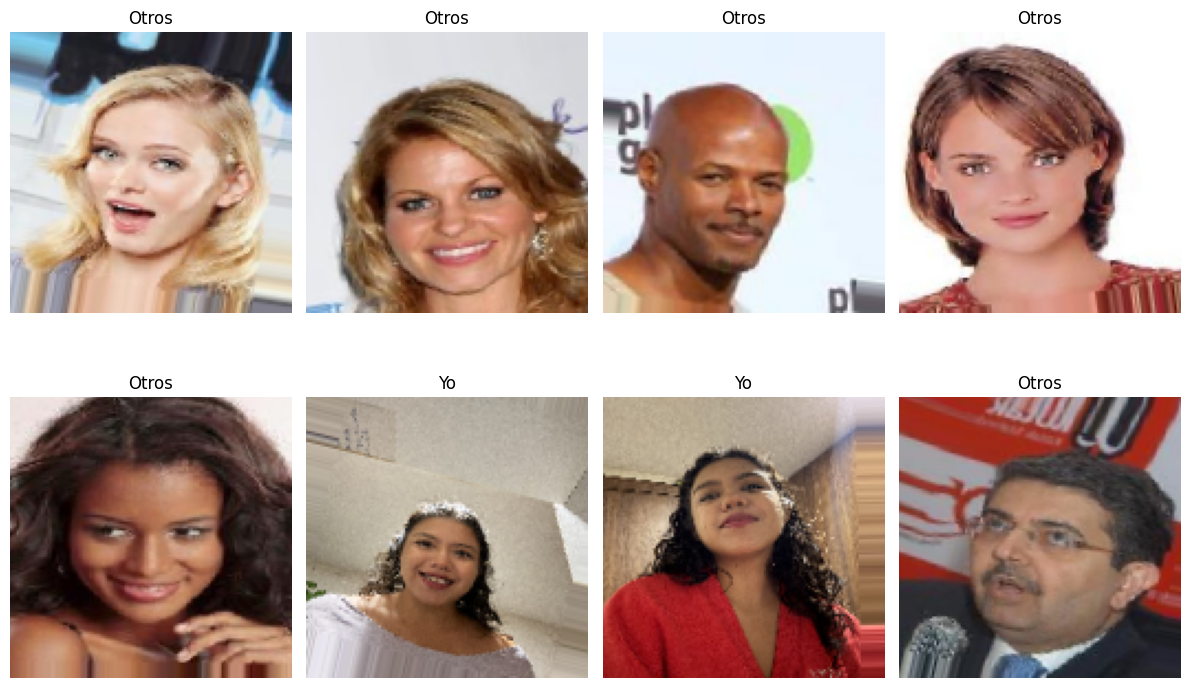

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(x_batch[i])
    plt.title("Yo" if y_batch[i] == 1 else "Otros")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Entrenamiento con capas convolucionales congeladas

Durante esta etapa se mantuvieron congeladas las capas convolucionales aprendidas mediante CelebA y solamente se entrenó el nuevo clasificador binario.

El modelo tenía un total de 109,889 parámetros, de los cuales 16,641 eran entrenables y 93,248 permanecían congelados.

Después de 10 épocas, se obtuvo una accuracy de entrenamiento de 94.29% y una pérdida de 0.2548. En el conjunto de validación se obtuvo una accuracy de 100% y una pérdida de 0.1978.

Estos resultados indican que las características aprendidas previamente con CelebA fueron útiles para adaptar el modelo a la clasificación entre las clases `yo` y `otros`.


In [69]:
history_face = model_face.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 531ms/step - binary_accuracy: 0.6667 - loss: 0.6183 - val_binary_accuracy: 0.7692 - val_loss: 0.4731
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 332ms/step - binary_accuracy: 0.7619 - loss: 0.4658 - val_binary_accuracy: 0.7692 - val_loss: 0.4337
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 352ms/step - binary_accuracy: 0.7619 - loss: 0.4348 - val_binary_accuracy: 0.7692 - val_loss: 0.3926
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 417ms/step - binary_accuracy: 0.7619 - loss: 0.4021 - val_binary_accuracy: 0.7692 - val_loss: 0.3515
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 429ms/step - binary_accuracy: 0.7619 - loss: 0.3700 - val_binary_accuracy: 0.7692 - val_loss: 0.3197
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 322ms/step - binary_accuracy: 0.8000 - loss: 0.3525 - val_binary_accuracy: 0.9615 - val_loss: 0.2925
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 325ms/step - binary_accuracy: 0.8667 - loss: 0.3224 - val_binary_accuracy: 0.9615 - val_loss: 0.2611
Epoch 8/10
7/7 ━━━━━

In [70]:
#Guardamos el modelo
model_face.save("/content/drive/MyDrive/modelo_face_etapa_b.keras")

Fine-tuning de la última capa convolucional

In [71]:
feature_extractor.layers[4].trainable = True

In [72]:
for i, layer in enumerate(feature_extractor.layers):
    print(i, layer.name, "→", layer.trainable)

0 conv2d → False
1 max_pooling2d → False
2 conv2d_1 → False
3 max_pooling2d_1 → False
4 conv2d_2 → True


In [73]:
optimizer = keras.optimizers.Adam(learning_rate=1e-5)

model_face.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["binary_accuracy"]
)

In [74]:
model_face.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_extractor (Sequential)  │ (None, 28, 28, 128)    │        93,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 90,497 (353.50 KB)

 Non-trainable params: 19,392 (75.75 KB)

In [75]:
optimizer = keras.optimizers.Adam(learning_rate=1e-5)

model_face.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["binary_accuracy"]
)

In [76]:
history_finetune = model_face.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5
)

Epoch 1/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 650ms/step - binary_accuracy: 0.9429 - loss: 0.2481 - val_binary_accuracy: 1.0000 - val_loss: 0.1967
Epoch 2/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 333ms/step - binary_accuracy: 0.9238 - loss: 0.2497 - val_binary_accuracy: 1.0000 - val_loss: 0.1960
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 317ms/step - binary_accuracy: 0.9429 - loss: 0.2450 - val_binary_accuracy: 1.0000 - val_loss: 0.1952
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 340ms/step - binary_accuracy: 0.9333 - loss: 0.2488 - val_binary_accuracy: 1.0000 - val_loss: 0.1943
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 461ms/step - binary_accuracy: 0.9143 - loss: 0.2532 - val_binary_accuracy: 1.0000 - val_loss: 0.1938


In [77]:
#Guardamos modelo
ruta_modelo_finetune = "/content/drive/MyDrive/modelo_face_etapa_c.keras"

model_face.save(ruta_modelo_finetune)

print("Modelo guardado en:", ruta_modelo_finetune)

Modelo guardado en: /content/drive/MyDrive/modelo_face_etapa_c.keras


## Fine-tuning

Para adaptar de manera más específica las características faciales aprendidas, se descongeló únicamente la última capa convolucional, correspondiente a la capa `Conv2D(128)`.

Las primeras capas convolucionales permanecieron congeladas. El modelo pasó a tener 90,497 parámetros entrenables y 19,392 parámetros no entrenables.

Se utilizó Adam con una tasa de aprendizaje reducida de `1e-5`, con el objetivo de realizar ajustes pequeños sobre las características previamente aprendidas.

Después de cinco épocas adicionales de fine-tuning, el modelo obtuvo una accuracy de entrenamiento de 91.43% y una pérdida de 0.2532. En validación mantuvo una accuracy de 100%, mientras que la pérdida disminuyó hasta 0.1938.

La mejora en la pérdida de validación respecto a la etapa anterior fue pequeña, pasando de 0.1978 a 0.1938. Por lo tanto, el fine-tuning permitió realizar un ajuste adicional de las representaciones, aunque el modelo ya presentaba un desempeño elevado antes de descongelar la última capa convolucional.


## Predicciones de validación

In [79]:
import numpy as np

# Predicciones del modelo
y_prob = model_face.predict(validation_generator)

# Convertir probabilidades a clases 0/1
y_pred = (y_prob.ravel() >= 0.5).astype(int)

# Etiquetas reales
y_true = validation_generator.classes

print("Etiquetas reales:     ", y_true)
print("Etiquetas predichas:  ", y_pred)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 423ms/step
Etiquetas reales:      [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1]
Etiquetas predichas:   [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1]


Matriz de confusión:
[[20  0]
 [ 0  6]]


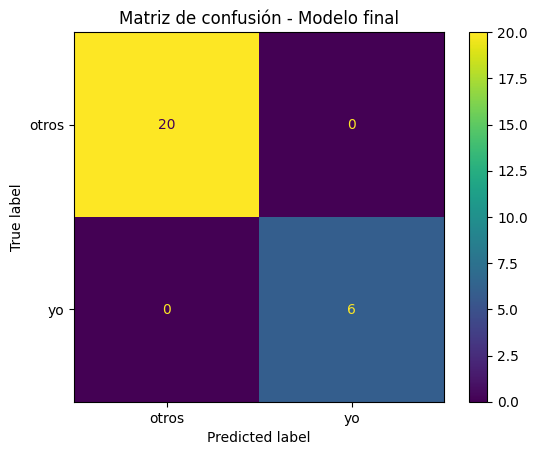

In [80]:
#Matriz de Confusion
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

print("Matriz de confusión:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["otros", "yo"]
)

disp.plot()
plt.title("Matriz de confusión - Modelo final")
plt.show()

In [81]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["otros", "yo"],
        digits=4
    )
)

              precision    recall  f1-score   support

       otros     1.0000    1.0000    1.0000        20
          yo     1.0000    1.0000    1.0000         6

    accuracy                         1.0000        26
   macro avg     1.0000    1.0000    1.0000        26
weighted avg     1.0000    1.0000    1.0000        26



## Curvas de entrenamiento

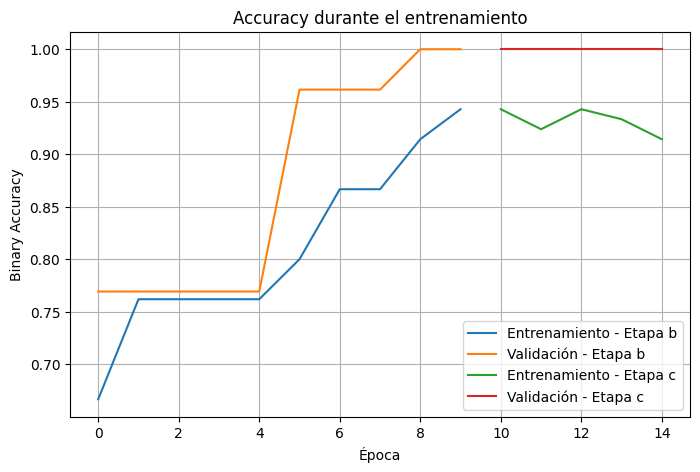

In [82]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    history_face.history["binary_accuracy"],
    label="Entrenamiento - Etapa b"
)

plt.plot(
    history_face.history["val_binary_accuracy"],
    label="Validación - Etapa b"
)

plt.plot(
    range(
        len(history_face.history["binary_accuracy"]),
        len(history_face.history["binary_accuracy"]) +
        len(history_finetune.history["binary_accuracy"])
    ),
    history_finetune.history["binary_accuracy"],
    label="Entrenamiento - Etapa c"
)

plt.plot(
    range(
        len(history_face.history["val_binary_accuracy"]),
        len(history_face.history["val_binary_accuracy"]) +
        len(history_finetune.history["val_binary_accuracy"])
    ),
    history_finetune.history["val_binary_accuracy"],
    label="Validación - Etapa c"
)

plt.xlabel("Época")
plt.ylabel("Binary Accuracy")
plt.title("Accuracy durante el entrenamiento")
plt.legend()
plt.grid(True)
plt.show()

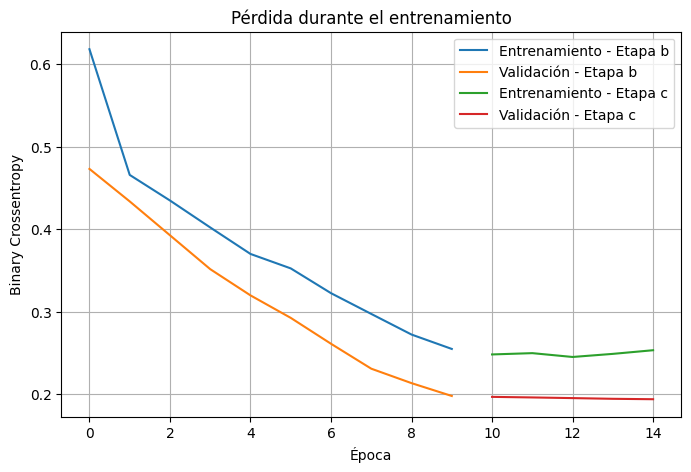

In [83]:
# Loss
plt.figure(figsize=(8, 5))

plt.plot(
    history_face.history["loss"],
    label="Entrenamiento - Etapa b"
)

plt.plot(
    history_face.history["val_loss"],
    label="Validación - Etapa b"
)

plt.plot(
    range(
        len(history_face.history["loss"]),
        len(history_face.history["loss"]) +
        len(history_finetune.history["loss"])
    ),
    history_finetune.history["loss"],
    label="Entrenamiento - Etapa c"
)

plt.plot(
    range(
        len(history_face.history["val_loss"]),
        len(history_face.history["val_loss"]) +
        len(history_finetune.history["val_loss"])
    ),
    history_finetune.history["val_loss"],
    label="Validación - Etapa c"
)

plt.xlabel("Época")
plt.ylabel("Binary Crossentropy")
plt.title("Pérdida durante el entrenamiento")
plt.legend()
plt.grid(True)
plt.show()

Los resultados muestran que la transferencia de aprendizaje permitió utilizar las representaciones obtenidas a partir del conjunto CelebA para construir un clasificador específico de dos clases.

Durante la etapa b, las capas convolucionales permanecieron congeladas y únicamente se entrenó el nuevo clasificador. El modelo alcanzó una accuracy de validación del 100%.

Posteriormente, durante la etapa c, se descongeló la última capa convolucional. La accuracy de validación permaneció en 100%, mientras que la pérdida de validación disminuyó ligeramente de 0.1978 a 0.1938. Esto indica que el fine-tuning realizó ajustes adicionales en las características aprendidas, aunque el cambio respecto al modelo con capas congeladas fue reducido.

Las curvas de entrenamiento muestran además una disminución progresiva de la pérdida durante la etapa b. Durante el fine-tuning, tanto la accuracy como la pérdida presentan fluctuaciones pequeñas, lo que es consistente con un ajuste de menor magnitud debido a la tasa de aprendizaje reducida.

La evaluación final produjo una matriz de confusión sin errores sobre las imágenes de validación disponibles: 20 imágenes de la clase `otros` y 6 imágenes de la clase `yo` fueron clasificadas correctamente. En consecuencia, precision, recall y F1-score fueron iguales a 1.000 para ambas clases en este conjunto.


## Limitaciones

Los resultados obtenidos deben interpretarse considerando las limitaciones del experimento.

La principal limitación es el reducido número de imágenes disponibles para la clase `yo`. El conjunto de validación contiene solamente seis imágenes propias, por lo que una accuracy de 100% representa únicamente el comportamiento sobre esas seis imágenes y no garantiza una capacidad de reconocimiento perfecta ante fotografías nuevas.

Además, las imágenes utilizadas pertenecen a un conjunto limitado de condiciones de captura. Cambios en iluminación, orientación del rostro, expresión facial, distancia respecto a la cámara, resolución o fondo podrían afectar el desempeño del modelo.

La clase `otros` también fue construida mediante una muestra relativamente pequeña de imágenes de CelebA. Por esta razón, los resultados no deben interpretarse como una evaluación general de un sistema de reconocimiento facial.

Finalmente, el modelo fue diseñado para fines académicos y experimentales. Un sistema de reconocimiento facial destinado a aplicaciones reales requeriría un conjunto de datos considerablemente mayor, protocolos de evaluación independientes y medidas adicionales de privacidad y seguridad.


## Conclusiones

En este trabajo se implementó un esquema de transferencia de aprendizaje para clasificación facial utilizando una CNN entrenada inicialmente con CelebA.

La CNN aprendió representaciones relacionadas con atributos faciales mediante una tarea de clasificación multietiqueta de 40 atributos. Posteriormente, sus capas convolucionales fueron reutilizadas como extractor de características para una nueva tarea binaria entre las clases `yo` y `otros`.

El uso de `GlobalAveragePooling2D` permitió transformar los mapas de características obtenidos por la última capa convolucional en una representación compacta sobre la cual se construyó el nuevo clasificador.

En la primera etapa de transferencia, con las capas convolucionales congeladas, el modelo alcanzó una accuracy de validación del 100%. El fine-tuning de la última capa convolucional mantuvo dicha accuracy y produjo una pequeña reducción adicional de la pérdida de validación.

La evaluación sobre las 26 imágenes de validación disponibles no presentó errores de clasificación, obteniéndose precision, recall y F1-score de 1.000 para ambas clases. Sin embargo, debido al reducido tamaño del conjunto de datos, estos resultados únicamente describen el comportamiento sobre las imágenes utilizadas y no permiten afirmar que el modelo tenga una capacidad de reconocimiento del 100% en situaciones generales.

El experimento demuestra, a nivel académico, cómo las características aprendidas mediante una tarea relacionada pueden reutilizarse y ajustarse para una nueva tarea de clasificación mediante transferencia de aprendizaje y fine-tuning.


## Resumen de resultados

| Modelo | Train Accuracy | Val Accuracy | Val Loss |
|---|---:|---:|---:|
| Etapa b | 0.9429 | 1.0000 | 0.1978 |
| Etapa c | 0.9143 | 1.0000 | 0.1938 |

La etapa c corresponde al fine-tuning de la última capa convolucional utilizando una tasa de aprendizaje de 1e-5.

In [84]:
#Para guardar las gráficas
plt.savefig("/content/drive/MyDrive/curva_accuracy.png", dpi=300, bbox_inches="tight")
plt.savefig("/content/drive/MyDrive/curva_loss.png", dpi=300, bbox_inches="tight")
plt.savefig("/content/drive/MyDrive/matriz_confusion.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>